# BMEB W4020: Circuits in the Brain 2025 Fall Homework \#5 Handout

<b>Author</b>: Shashwat Shukla <shashwat.shukla@columbia.edu> Bruce Yi Bu <yb2520@columbia.edu>

Based on previous work from the Bionet Group.

<b>Copyright 2012-2025</b> Shashwat Shukla, Bruce Yi Bu, Tingkai Liu, and Aurel A. Lazar

### Names and UNIs
Alexander Speer aes2376 / Andre Perez avp2141

**NOTE**: Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel$\rightarrow$Restart) and then **run all cells** (in the menubar, select Cell$\rightarrow$Run All).
make
Make sure you fill up your name and collaborators below:

## PROBLEM \#1:
The dendritic processing filter in figure below is modeled with a causal linear kernel
$$
h(t)= c \cdot e^{-\alpha t} \left[  \frac{(\alpha t)^2}{2!} -
\frac{(\alpha t)^4}{4!}\right]
$$
with
$t\in[0,0.1]$ [s], $c = 3$ and $\alpha=150$.


<center>
    <img src='fig0.png' width=700></img>
</center>


The Biophysical Spike Generator (BSG) in the figure above is taken to be an Asynchronous Sigma Delta Modulator (ASDM). Identify the impulse response of the filter using 3 different sets of random stimuli (*each set can be 1 or more random stimuli with the same bandwidth -- see Note 1 -- we will use 4 here* ) in the _trignometric polynomial_ basis with bandwidth $\Omega = 2\pi \cdot 25$ rad/s, $\Omega = 2\pi \cdot 50$ rad/s and $\Omega = 2\pi \cdot 100$ rad/s.

**Plot:**
1. For each stimuli, plot the signal $u=u(t)$ and its Fourier transform (one stimulus for each bandwidth would suffice).
2. Implement the algorithm to identify the filter. Using each stimuli, find the filter projected onto the space of input signals. Show the Fourier transform of the recovered filters.
3. Compute the MSE between $h$ and the recovered filters for $t\in[0, 0.1]$ s.

**Note**
1. Recovery is better with multiple I/O Pairs, use theorem 11.3
2. Solve for $\mathbf{\Phi}$ using the analytical solution as in Lemma 11.3/theorem 11.3


**References**
1. Ch 11:Python Notebooks Example I: SISO [Filter]-[Ideal IAF] Circuit, Single I/O Pair
1. Ch 11:Python Notebooks Example 2: SISO [Filter]-[Ideal IAF] Circuit, Multiple I/O Pair
2. Ch 11.2 Identifying the [Filter]-[Ideal IAF] Circuit (I)
3. Ch 11.3 Identifying the [Filter]-[Ideal IAF] Circuit (II)


## PROBLEM \#2:
The dendritic processing circuit in the figure below consists of two linear filters with impulse responses $h_1(t)$ and $h_2(t)$, the sum of whose responses $v(t)$, serves as the input to an AER neuron (with thresholding and feedback). The signals ${\bf u(t)} = (u_1(t), u_2(t))$ are in the _trigonometric polynomial_ space with bandwidth $\Omega$.

<center>
    <img src='fig1.png' width=500></img>
</center>

1. Write down the t-transform for the circuit.
2. Find an algorithem for identifying the impulse response of the two filters, $h_1(t)$ and $h_2(t)$, using stimuli in the __trigonometric polynomial__ space. Describe the process in steps and write down any relavent equations/matrices in sufficient detail; clearly define additional notations if needed and ensure consistency in your notation (also try to use notation consistent with the chapters).

No code is required and please use markdown for your answer.

# **Cell 1**

In [1]:
#Mount the drive and then point to HW4
from google.colab import drive
drive.mount('/content/drive')

import sys, importlib

# Make sure you're not loading a stale/local copy of compneuro
if 'compneuro' in sys.modules:
    del sys.modules['compneuro']
#the right path we should be using
sys.path.insert(0, "/content/drive/MyDrive/CCircuits/hw5")

import numpy as np
import math

import matplotlib.pyplot as plt
import typing as tp
from scipy import signal, fft
from scipy.linalg import block_diag
from scipy.integrate import cumulative_trapezoid as cumtrapz


from compneuro.utils.trig_poly import (
    get_coeffs_from_signal,
    get_signal_from_coeffs,
    random_trig_signal,
)

np.random.seed(0)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Cell 2**

In [2]:
# change this!
f = 25  # set the input signal bandwidth, [Hz]
# f = 50
# f = 100

# **Cell 3**

In [3]:
dt = 1e-5  # time step [s]
L = 20
W = 2 * np.pi * f
T = 2 * np.pi * L / W
t = np.arange(-T / 2, T / 2, dt)

# **Cell 4**

In [4]:
# generate 4 input signals for a given bandwidth

# you might wanna repeat this 3 times for each f and get 3 u's
N_sig = 4  # number of random input signals with the same bandwidth

u_l = []
u = []
for n in range(N_sig):
    _u_l, _u = random_trig_signal(L, T, t, rng=1 + n)
    u_l.append(_u_l)
    u.append(_u)

u_l = np.vstack(u_l)
u = np.vstack(u)

# **Cell 5**

Generating and plotting stimulus for f = 25 Hz


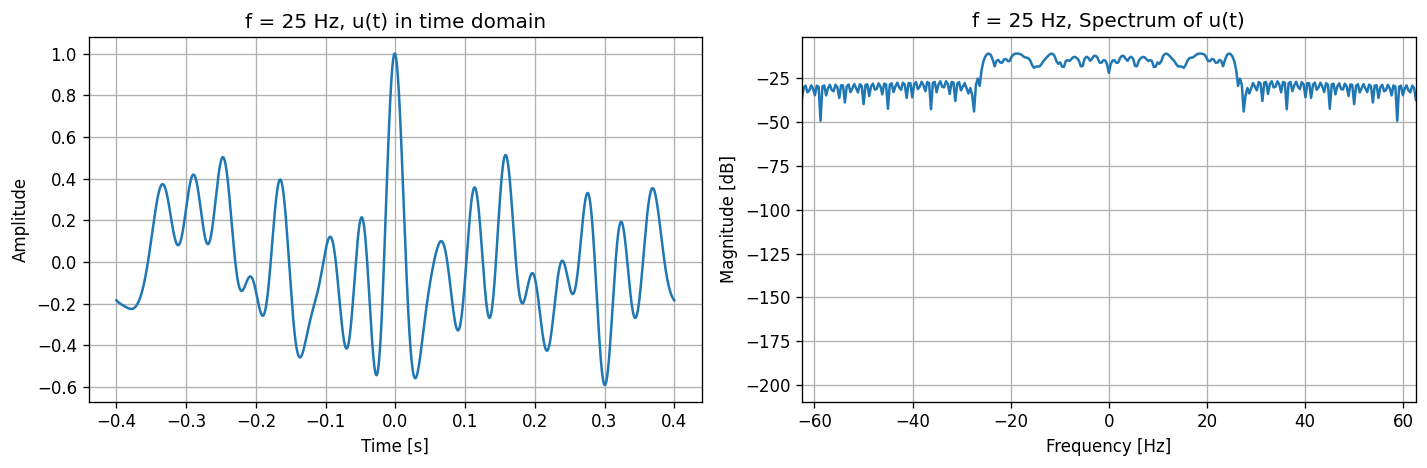

Generating and plotting stimulus for f = 50 Hz


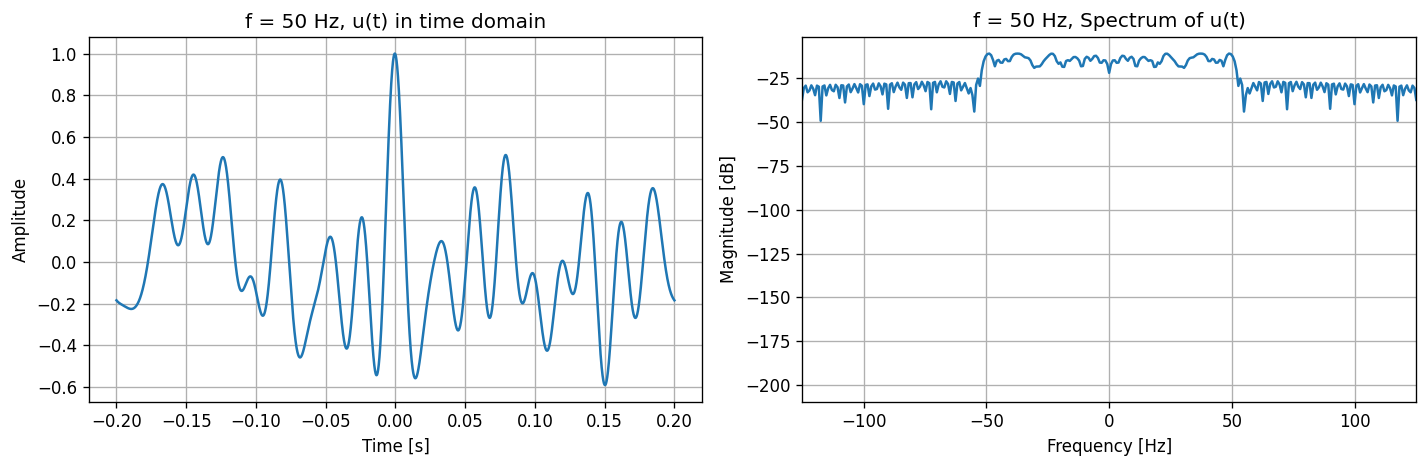

Generating and plotting stimulus for f = 100 Hz


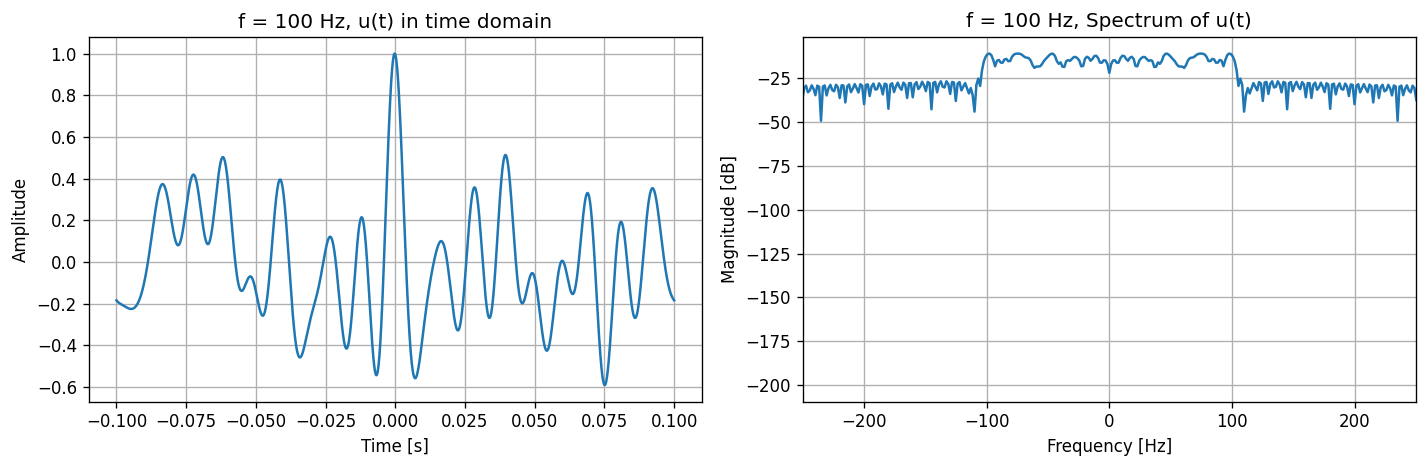

In [5]:
# plot input stimuli and their Fourier transform (one stimulus for each bandwidth would suffice)



def plot_time_and_spectrum(u_sig, t, f, title_prefix=""):
  #compute what the sampling interval is
    dt = t[1] - t[0]
    Nfft = int(2 ** (np.ceil(np.log2(len(u_sig))) + 1))
    spec = fft.fftshift(fft.fft(u_sig, n=Nfft)) / len(u_sig)
    freq = fft.fftshift(fft.fftfreq(Nfft, dt))

    #time domain and freq. domain suplot layout we choose
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=120)

    axes[0].plot(t, u_sig)
    axes[0].set_title(f"{title_prefix} u(t) in time domain")
    axes[0].set_xlabel("Time [s]")
    axes[0].set_ylabel("Amplitude")
    axes[0].grid(True)

    axes[1].plot(freq, 10 * np.log10(np.abs(spec) + 1e-20))
    axes[1].set_title(f"{title_prefix} Spectrum of u(t)")
    axes[1].set_xlabel("Frequency [Hz]")
    axes[1].set_ylabel("Magnitude [dB]")
    axes[1].set_xlim([-2.5 * f, 2.5 * f])
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

# also lets add the plots in for 50, and 100 in as well
bandwidths = [25, 50, 100]

for f_test in bandwidths:
    print(f"Generating and plotting stimulus for f = {f_test} Hz")

    # we will have to recompute the trig-poly space for this f here
    L = 20
    W_test = 2 * np.pi * f_test
    T_test = 2 * np.pi * L / W_test
    t_test = np.arange(-T_test / 2, T_test / 2, dt)

    # lets generate the stimulus
    u_l_test, u_test = random_trig_signal(L, T_test, t_test, rng=1)

    # plot the time and the spectrum
    plot_time_and_spectrum(
        u_test,
        t_test,
        f_test,
        title_prefix=f"f = {f_test} Hz,"
    )


# **Cell 6**

t_filt.shape: (80000,)
Non zero h samples: 10000
h support approx from 2.0003443346183758e-13 to 0.09999000000030003


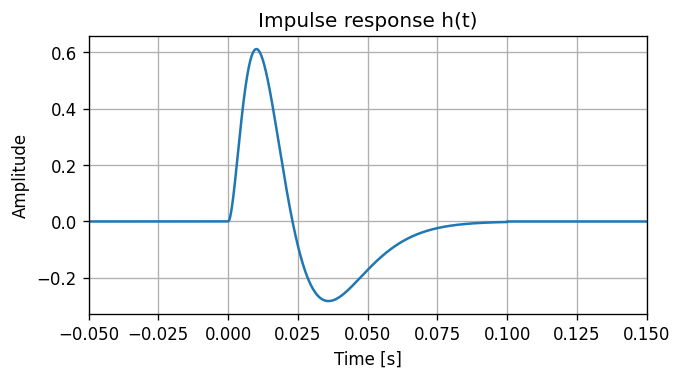

In [6]:
# specify the filter h
T1, T2 = 0, 0.1    # specify T1 and T2
a, c = 150, 3.0   # set the filter parameter
t_filt = np.arange(-T / 4, T * 3 / 4, dt)  # set the time course of the filter, [s]

h = np.zeros_like(t_filt)
mask = np.logical_and(t_filt >= T1, t_filt <= T2)

#just computing the defined filter,
#zero everywhere else
# h(t) = c * exp(-a t) * [ (a t)^2 / 2! - (a t)^4 / 4! ]
t_pos = t_filt[mask] #restrinct the compututiation for the nonzero support.
h[mask] = c * np.exp(-a * t_pos) * (
    (a * t_pos) ** 2 / math.factorial(2)
    - (a * t_pos) ** 4 / math.factorial(4)
)

#sanity checks
print("t_filt.shape:", t_filt.shape)
print("Non zero h samples:", np.count_nonzero(h))
print("h support approx from", t_filt[mask][0], "to", t_filt[mask][-1])

# just a quick plot to view the waveform
plt.figure(figsize=(6, 3), dpi=120)
plt.plot(t_filt, h)
plt.xlim([-0.05, 0.15])
plt.title("Impulse response h(t)")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()


# **Cell 7**

In [7]:
# Specify ASDM parameters
delta = 0.001  # threshold
bias = 1.0 # bias
C = 1.0  # capacitance

# **Cell 8**

In [8]:
# encode ASDM

#trying to use the same t-transform as in the ideal IAF neuron seen in the chapters

#switching times like chapter 11 also

from scipy.signal import convolve

#period structure
#living in finite dim. space
def cconv(u: np.ndarray, h: np.ndarray, dx: float = 1.0, use_fft: bool = True) -> np.ndarray:
    """
    This is meant to be a Circular convolution, as was
    used in the Ch. 11 trig-polynomial examples.
    """
    Nfft = max(len(u), len(h))
    if use_fft:
        v = dx * np.real(np.fft.ifft(np.fft.fft(u, n=Nfft) * np.fft.fft(h, n=Nfft)))
        return v[: len(u)]
    v = dx * convolve(np.tile(u, 2), h, mode="full")
    return v[len(u): len(u) + len(u)]

#also should be somewhat of the same structure in the prev. examples.
def ideal_iaf_rt_encode(
    u: np.ndarray,
    t: np.ndarray,
    b: float,
    d: float,
    k: float,
    DeltaVar: float = 0.0,
    RandomInit: bool = True,
    rng: int = None,
):
    """
    Here is the ideal IAF encoder with the inclusion of the  optional noisy thresholds.
    We are going to treat the ASDM switching times as these spike times,
    and then the t-transform should be identical.
    """
    sigma = DeltaVar
    rng = np.random.RandomState(rng)
    dt = t[1] - t[0]

    s = np.zeros_like(t, dtype=bool)
    v = np.zeros_like(t)
    delta_v = [d + sigma * rng.randn()]

    if RandomInit:
        v[0] = 0.9 * delta_v[-1] * rng.rand()

    for k_idx in range(1, len(t)):
        dV = (b + 0.5 * (u[k_idx] + u[k_idx - 1])) / k
        v[k_idx] = v[k_idx - 1] + dt * dV
        if v[k_idx] >= delta_v[-1]:
            v[k_idx] -= delta_v[-1]
            s[k_idx] = True
            delta_v.append(d + sigma * rng.randn())

    return s, v, delta_v


# And then this section here is going to filter all of the inputs and then encode
#wqhat we get with the ASDM/IAF equivalent

N_sig, N_t = u.shape
v = np.zeros_like(u)  # these are going to be the filtered outputs essentially v = u * h
s = np.zeros_like(u, dtype=bool)  # and then this line is the spike masks for each of the stimulus

h_causal = h[t_filt >= 0]  # we are only giong to use the causal part for filtering

for i in range(N_sig):
    # here we start implementing the dendritic filtering
    v[i] = cconv(u[i], h_causal, dx=dt)
    # and then this is going to be the ASDM / Ideal IAF encoding (which should be the same t-transform)
    s[i], v_mem, delta_v = ideal_iaf_rt_encode(
        v[i], t, bias, delta, C, DeltaVar=0.0, RandomInit=True, rng=1 + i
    )
    print(f"Signal {i}: number of spikes = {s[i].sum()}")
#just make sure that we are seeing everything correctly.
print("v shape:", v.shape, "(N_sig, N_t)")
print("s (spike mask) shape:", s.shape)


Signal 0: number of spikes = 799
Signal 1: number of spikes = 800
Signal 2: number of spikes = 800
Signal 3: number of spikes = 800
v shape: (4, 80000) (N_sig, N_t)
s (spike mask) shape: (4, 80000)


# **Cell 9**

Number of spikes needed (2L+2): 42
Number of spikes used: 3199
h_hat shape: (80000,)
MSE for f = 25 Hz over [0, 0.1] s: -67.86 dB
Updated mse_results: {25: np.float64(-67.86357387554366)}


/tmp/ipython-input-2981997605.py:140: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  np.trapz((h[mask_support] - h_hat[mask_support]) ** 2, dx=dt) / num_pts


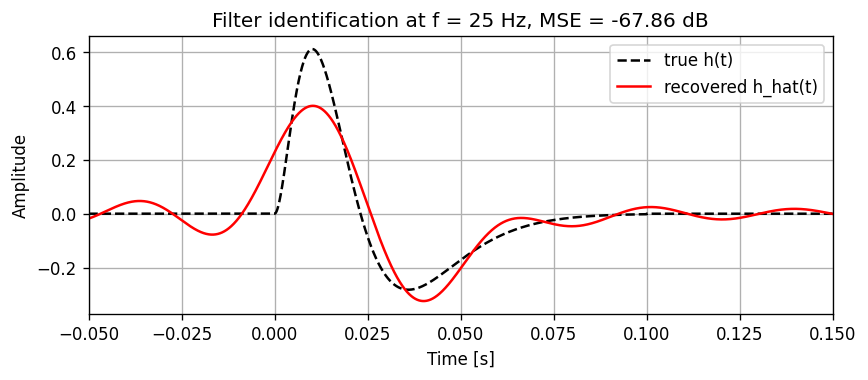

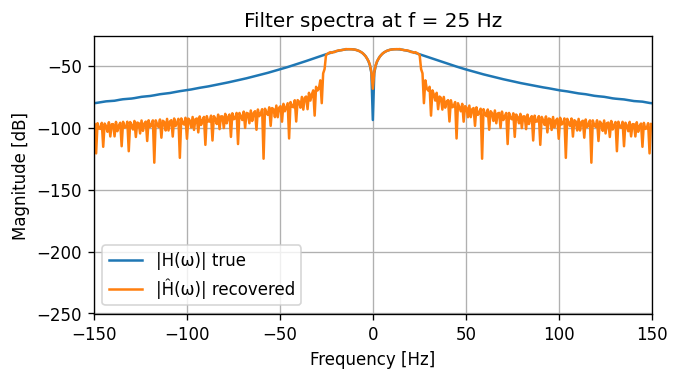

In [9]:
# identify h
# q matrix
# phi matrix

def identify_h_ideal_iaf_trig(
    t: np.ndarray,
    t_Ph: np.ndarray,
    u: np.ndarray,
    W: float,
    L: int,
    b: float,
    d: float,
    k: float,
    s: np.ndarray,
    SmoothFactor: float = 1e-11,
    RandomThreshold: bool = False,
    tau: tp.Tuple[float] = None,
    rcond: float = None,
):
    """
    Okay this function is going to be the Trig-polynomial identification
    of the dendritic filter with teh cascade using the an IAF/ASDM that we see in
    chp.11

    These are all of the Arguments well be using in:
        t: time vector of signals (length N_t)
        t_Ph: time vector on which we want the recovered filter
        u: input stimuli, shape (N_sig, N_t)
        W: bandwidth in rad/s
        L: order of trig-polynomial space
        b: bias of ASDM/IAF
        d: threshold
        k: capacitance
        s: spike mask, shape (N_sig, N_t)
    """
    if tau is None:
        tau = [t[0], t[-1]]

    N_sig, N_t = u.shape
    dt = t[1] - t[0]

    # here are all of the spike times for each of our stimulus that is going
    #to end up being restricted to a period of [tau[0], and tau[1]]
    tk = [
        t[np.logical_and.reduce([s[i], t >= tau[0], t <= tau[1]])]
        for i in range(N_sig)
    ]

    # this line just records the total number of spikes
    N_spk = int(np.sum(s))

    # should hopefully build up q: k*d - b * Δt for each inter-spike interval
    q = np.concatenate([k * d - b * np.diff(_tk) for _tk in tk])

    # Andre this is what I was talking about with the trig-polynomial space parameters
    T_per = 2 * np.pi * L / W  #just hte period of RKHS?
    e_l = lambda m, tt: np.exp(1j * m * W / L * tt) / np.sqrt(T_per)

    # taking the fourier coefficients  of inputs by convention of cpt 11
    u_l = fft.fft(u, axis=1) * np.sqrt(T_per) / N_t

    #build Φ analytically lemma 11.3 <-- found in
    Phi = np.zeros((len(q), 2 * L + 1), dtype=complex)

    row_idx = [-1]
    for i in range(N_sig):
        # finding the rows for the  stimulus i
        row_idx = row_idx[-1] + 1 + np.arange(len(tk[i]) - 1)
        # this si going to be m from -L to 0 and then the rest filled by conjugate symmetry
        for m in range(-L, 1):
            if m == 0:
                Phi[row_idx, L] = u_l[i, 0] * np.diff(tk[i])
            else:
                Phi[row_idx, m + L] = (
                    u_l[i, m]
                    * np.sqrt(T_per)
                    / (1j * m * W / L)
                    * (e_l(m, tk[i][1:]) - e_l(m, tk[i][:-1]))
                )
        # this si the positive m found using symmetry
        Phi[row_idx, L + 1 :] = np.conj(Phi[row_idx, (L - 1) :: -1])

    Phi = np.conj(Phi)

    # and then this block is just to solve for the spectral coefficients of
    #h_l by using the  pseudo-inverse or also the regularized LS
    if RandomThreshold:
        PhiPhi = np.conj(Phi.T) @ Phi
        h_l = np.linalg.lstsq(
            PhiPhi + len(q) * SmoothFactor * np.eye(len(PhiPhi)),
            np.conj(Phi.T) @ q,
            rcond=rcond,
        )[0]
    else:
        h_l = np.linalg.pinv(Phi, rcond=rcond) @ q

    # This si to reconstruct the filter from the fourier coefficientsbasically the inverse FFT style
    h_l_pad = np.zeros(t_Ph.shape, dtype=complex)
    h_l_pad[: L + 1] = h_l[L:]
    h_l_pad[-L:] = h_l[:L]
    h_l_pad = np.conj(h_l_pad)

    Ph_rec = np.real(fft.ifft(h_l_pad)) * len(t_Ph) / np.sqrt(T_per)

    # and then this shift so that we can see that t_Ph is going to end up matching the desired time course
    idx_shift = int(np.floor(((t_Ph[0] + T_per / 2) % T_per) / dt))
    Ph_rec = np.concatenate([Ph_rec[idx_shift:], Ph_rec[:idx_shift]])
    #diff sanity checks
    print(f"Number of spikes needed (2L+2): {2 * L + 2}")
    print(f"Number of spikes used: {N_spk}")

    return Ph_rec, N_spk


# then this section is going to be running the identification for each of the current bandwidth f
#might just stick with 25hz and then plot the rest in cell 10.

#here this can be used to identify h (projected into the trig space)
h_hat, N_spk_used = identify_h_ideal_iaf_trig(
    t=t,
    t_Ph=t_filt,
    u=u,
    W=W,
    L=L,
    b=bias,
    d=delta,
    k=C,
    s=s,
    RandomThreshold=False,
    rcond=1e-4,
)

print("h_hat shape:", h_hat.shape)

#  here we are goingt to compute the MSE between the true h and then the recovered h_hat over the interval 0 0.1s
mask_support = np.logical_and(t_filt >= T1, t_filt <= T2)
num_pts = np.sum(mask_support)

rmse = np.sqrt(
    np.trapz((h[mask_support] - h_hat[mask_support]) ** 2, dx=dt) / num_pts
) / np.max(np.abs(h[mask_support]))
mse_db = 10 * np.log10(rmse ** 2)

print(f"MSE for f = {f} Hz over [0, 0.1] s: {mse_db:.2f} dB")

#this is just going to be stored in a global dict so that we can see that
#Cell 10 is going to be able to aggregate across the diff. bandwidths
if "mse_results" not in globals():
    mse_results = {}
mse_results[int(f)] = mse_db
print("Updated mse_results:", mse_results)

# here this should be plotting the time-domain basically just true vs the recovered filter
plt.figure(figsize=(8, 3), dpi=120)
plt.plot(t_filt, h, "k--", label="true h(t)")
plt.plot(t_filt, h_hat, "r", label="recovered h_hat(t)")
plt.xlim([-0.05, 0.15])
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title(f"Filter identification at f = {f} Hz, MSE = {mse_db:.2f} dB")
plt.grid(True)
plt.legend()
plt.show()

# and then finally lets just tlot the fourier magnitude spectra of h and h_hat
Nfft = int(2 ** np.ceil(np.log2(len(h))))
H = fft.fftshift(fft.fft(h, n=Nfft)) / len(h)
H_hat = fft.fftshift(fft.fft(h_hat, n=Nfft)) / len(h_hat)
freq = fft.fftshift(fft.fftfreq(Nfft, dt))

plt.figure(figsize=(6, 3), dpi=120)
plt.plot(freq, 20 * np.log10(np.abs(H) + 1e-12), label="|H(ω)| true")
plt.plot(freq, 20 * np.log10(np.abs(H_hat) + 1e-12), label="|Ĥ(ω)| recovered")
plt.xlim([-150, 150])
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude [dB]")
plt.title(f"Filter spectra at f = {f} Hz")
plt.grid(True)
plt.legend()
plt.show()


# **Cell 10**

Running the full identification pipeline for f = 25 Hz
This generated u with shape: (4, 80000)
  f=25 Hz, signal 0: #spikes = 799
  f=25 Hz, signal 1: #spikes = 800
  f=25 Hz, signal 2: #spikes = 800
  f=25 Hz, signal 3: #spikes = 800
Number of spikes needed (2L+2): 42
Number of spikes used: 3199
  Bandwidth f = 25 Hz: spikes used = 3199, MSE = -67.86 dB


/tmp/ipython-input-1224681415.py:92: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  np.trapz((h[mask_support] - h_hat[mask_support]) ** 2, dx=dt) / num_pts


Running the full identification pipeline for f = 50 Hz
This generated u with shape: (4, 40000)
  f=50 Hz, signal 0: #spikes = 399
  f=50 Hz, signal 1: #spikes = 400
  f=50 Hz, signal 2: #spikes = 400
  f=50 Hz, signal 3: #spikes = 400
Number of spikes needed (2L+2): 42
Number of spikes used: 1599
  Bandwidth f = 50 Hz: spikes used = 1599, MSE = -78.97 dB
Running the full identification pipeline for f = 100 Hz
This generated u with shape: (4, 20000)
  f=100 Hz, signal 0: #spikes = 199
  f=100 Hz, signal 1: #spikes = 200
  f=100 Hz, signal 2: #spikes = 200
  f=100 Hz, signal 3: #spikes = 200
Number of spikes needed (2L+2): 42
Number of spikes used: 799
  Bandwidth f = 100 Hz: spikes used = 799, MSE = -72.06 dB


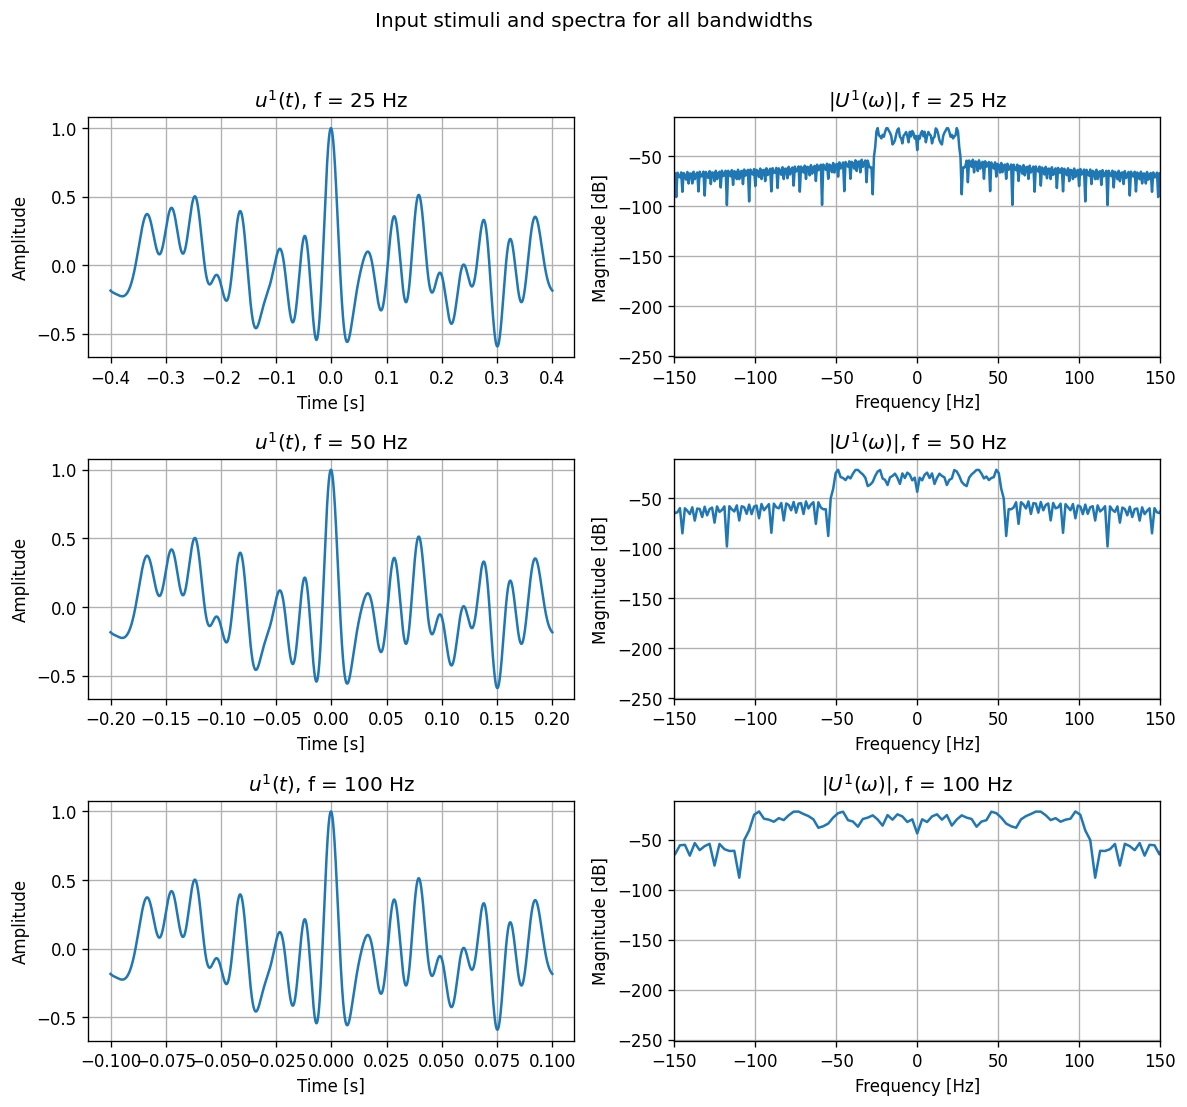

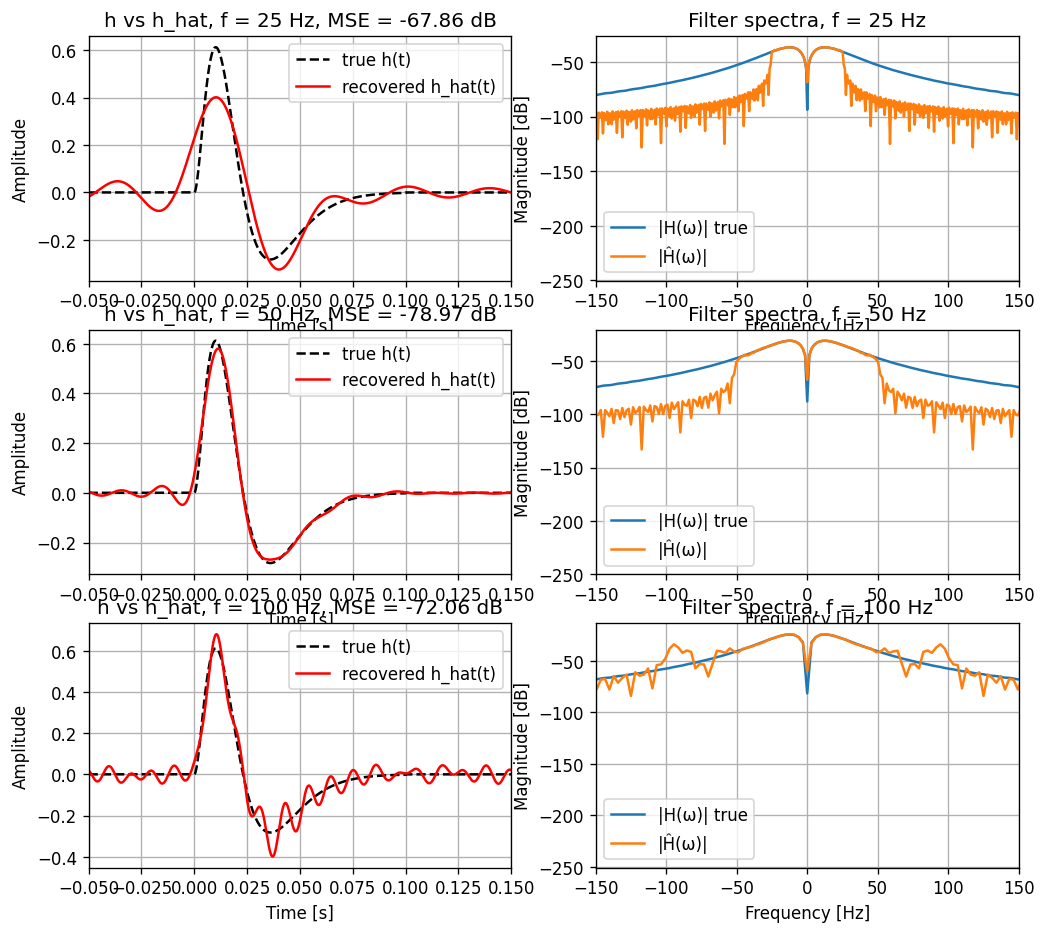

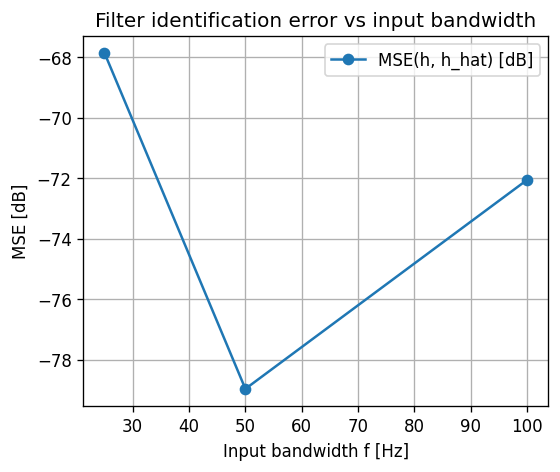


Final MSE results by bandwidth: {25: np.float64(-67.86357387554366), 50: np.float64(-78.96847684595014), 100: np.float64(-72.05882332402895)}


In [10]:
# plot results across three bandwidth, clearly label and title the plots

import math

#lets try all 3 of the bandwidths
f_list = [25, 50, 100]


dt = 1e-5
L = 20
T1, T2 = 0.0, 0.1
a, c = 150.0, 3.0
delta = 0.001  #threshold
bias = 1.0  #bais
C = 1.0 # the cap
N_sig = 4

mse_db_list = []

# this is to hold the figures all of the inputs. the spectra, and the filters + spectra
fig_u, axes_u = plt.subplots(
    len(f_list), 2, figsize=(10, 3 * len(f_list)), dpi=120
)
fig_h, axes_h = plt.subplots(
    len(f_list), 2, figsize=(10, 3 * len(f_list)), dpi=120
)
#sanity as well
for i, f in enumerate(f_list):
    print(f"Running the full identification pipeline for f = {f} Hz")

    # we will just havet to recompute  this space for this special bandwidth
    W = 2 * np.pi * f
    T = 2 * np.pi * L / W
    t = np.arange(-T / 2, T / 2, dt)

    # this is just making sure to generate 4 random trig input signals
    u_l = []
    u = []
    for n in range(N_sig):
        _u_l, _u = random_trig_signal(L, T, t, rng=1 + n)
        u_l.append(_u_l)
        u.append(_u)
    u_l = np.vstack(u_l)
    u = np.vstack(u)
    print("This generated u with shape:", u.shape)

    # and this this is to define the true filter h(t) for this period
    t_filt = np.arange(-T / 4, 3 * T / 4, dt)
    h = np.zeros_like(t_filt)
    mask = (t_filt >= T1) & (t_filt <= T2)
    # this should be in order to use t_rel = t - T1 so that the formula is going to match
    #what the hew3 soltuions said Andre.
    t_rel = t_filt[mask] - T1
    h[mask] = c * np.exp(-a * t_rel) * (
        (a * t_rel) ** 2 / math.factorial(2)
        - (a * t_rel) ** 4 / math.factorial(4)
    )

    # this is meant to filter and also to encode via the ASDM/IAF
    h_causal = h[t_filt >= 0]
    v = np.zeros_like(u)
    s = np.zeros_like(u, dtype=bool)

    for j in range(N_sig):
        v[j] = cconv(u[j], h_causal, dx=dt)
        s[j], _, _ = ideal_iaf_rt_encode(
            v[j], t, bias, delta, C,
            DeltaVar=0.0, RandomInit=True, rng=1 + j
        )
        print(f"  f={f} Hz, signal {j}: #spikes = {s[j].sum()}")

    # This chunk is going to iudentify the filter using trig method
    #found in chapter 11 as well
    h_hat, N_spk_used = identify_h_ideal_iaf_trig(
        t=t,
        t_Ph=t_filt,
        u=u,
        W=W,
        L=L,
        b=bias,
        d=delta,
        k=C,
        s=s,
        RandomThreshold=False,
        rcond=1e-4,
    )

    # then we are going to compute the MSE over over the same specified interval
    mask_support = (t_filt >= T1) & (t_filt <= T2)
    num_pts = np.sum(mask_support)
    rmse = np.sqrt(
        np.trapz((h[mask_support] - h_hat[mask_support]) ** 2, dx=dt) / num_pts
    ) / np.max(np.abs(h[mask_support]))
    mse_db = 10 * np.log10(rmse ** 2)
    mse_db_list.append(mse_db)

    print(
        f"  Bandwidth f = {f} Hz: spikes used = {N_spk_used}, "
        f"MSE = {mse_db:.2f} dB"
    )


    #just the  plots for this bandwidth, the input and the spectrum.
    ax_t = axes_u[i, 0] if len(f_list) > 1 else axes_u[0]
    ax_f = axes_u[i, 1] if len(f_list) > 1 else axes_u[1]

    ax_t.plot(t, u[0])
    ax_t.set_title(f"$u^1(t)$, f = {f} Hz")
    ax_t.set_xlabel("Time [s]")
    ax_t.set_ylabel("Amplitude")
    ax_t.grid(True)

    Nfft_u = int(2 ** np.ceil(np.log2(len(u[0]))))
    U = fft.fftshift(fft.fft(u[0], n=Nfft_u)) / len(u[0])
    freq_u = fft.fftshift(fft.fftfreq(Nfft_u, dt))

    ax_f.plot(freq_u, 20 * np.log10(np.abs(U) + 1e-12))
    ax_f.set_title(f"$|U^1(\\omega)|$, f = {f} Hz")
    ax_f.set_xlabel("Frequency [Hz]")
    ax_f.set_ylabel("Magnitude [dB]")
    ax_f.set_xlim([-150, 150])
    ax_f.grid(True)

    #these are the plots for this bandwidth, both with the h vs h_hat and
    #then followed by the spectra
    ax_ht = axes_h[i, 0]
    ax_hf = axes_h[i, 1]

    ax_ht.plot(t_filt, h, "k--", label="true h(t)")
    ax_ht.plot(t_filt, h_hat, "r", label="recovered h_hat(t)")
    ax_ht.set_xlim([-0.05, 0.15])
    ax_ht.set_title(f"h vs h_hat, f = {f} Hz, MSE = {mse_db:.2f} dB")
    ax_ht.set_xlabel("Time [s]")
    ax_ht.set_ylabel("Amplitude")
    ax_ht.grid(True)
    ax_ht.legend()

    Nfft_h = int(2 ** np.ceil(np.log2(len(h))))
    H = fft.fftshift(fft.fft(h, n=Nfft_h)) / len(h)
    H_hat = fft.fftshift(fft.fft(h_hat, n=Nfft_h)) / len(h_hat)
    freq_h = fft.fftshift(fft.fftfreq(Nfft_h, dt))

    ax_hf.plot(freq_h, 20 * np.log10(np.abs(H) + 1e-12), label="|H(ω)| true")
    ax_hf.plot(freq_h, 20 * np.log10(np.abs(H_hat) + 1e-12), label="|Ĥ(ω)|")
    ax_hf.set_xlim([-150, 150])
    ax_hf.set_title(f"Filter spectra, f = {f} Hz")
    ax_hf.set_xlabel("Frequency [Hz]")
    ax_hf.set_ylabel("Magnitude [dB]")
    ax_hf.grid(True)
    ax_hf.legend()

# Just make the tidy layout for the diff multi-band figures we generate
fig_u.suptitle("Input stimuli and spectra for all bandwidths", y=1.02)
fig_u.tight_layout()
plt.show(fig_u)

fig_h.suptitle("Recovered filters across bandwidths", y=1.02)
fig_h.tight_layout()
plt.show(fig_h)

# create a little sumamry table for debugging
mse_db_list = np.array(mse_db_list)

plt.figure(figsize=(5, 4), dpi=120)
plt.plot(f_list, mse_db_list, "o-", label="MSE(h, h_hat) [dB]")
plt.xlabel("Input bandwidth f [Hz]")
plt.ylabel("MSE [dB]")
plt.title("Filter identification error vs input bandwidth")
plt.grid(True)
plt.legend()
plt.show()

print("\nFinal MSE results by bandwidth:", dict(zip(f_list, mse_db_list)))


# **PROBLEM \#2:**

1. Write down the t-transform for the circuit.

# **2.1 t-transform for the two-filter dendritic circuit**

The circuit is meant to receive the two-dimensional input:
$$
\mathbf{u}(t) = (u_1(t),\,u_2(t)).
$$

After this, each component is then going to be passed through a linear dendritic filter in combination with all of the impulse responses:  
$$
h_1(t), \qquad h_2(t),
$$
which is then going to produce  
$$
v_1(t) = (h_1 * u_1)(t), \qquad
v_2(t) = (h_2 * u_2)(t).
$$

This means that the total current that is going to end up entering the AER/IAF neuron is:

$$
v(t) = v_1(t) + v_2(t)
      = (h_1*u_1)(t) + (h_2*u_2)(t).
$$

And the neuron is going to be the ideal IAF neuron with the capacitance of $\kappa$, a threshold equal to $\delta$, and also a bias of $b$.  
If $\{t_k\}$ are defined as a series of successive spike times, then that means that integrating the membrane equation is going to give:

$$
\kappa\delta
=
\int_{t_k}^{t_{k+1}} (b + v(t))\,dt .
$$

And then when you are rearranging, it yields the t-transform samples

$$
q_k
=
\int_{t_k}^{t_{k+1}} v(t)\,dt
=
\kappa\delta - b\,(t_{k+1}-t_k).
$$

And then if you are going to substitute the expression for $v(t)$, you get:

$$
q_k
=
\sum_{j=1}^{2}
\int_{t_k}^{t_{k+1}}
(h_j * u_j)(t)\,dt ,
$$

which then expands to  

$$
\boxed{
q_k =
\sum_{j=1}^{2}
\int_{\mathbb{R}}
h_j(\tau)
\left[
\int_{t_k}^{t_{k+1}}
u_j(t-\tau)\,dt
\right]
d\tau
}
$$

At last, this sequence $\{q_k\}$ is going to be the t-transform of the two-filter dendritic circuit that is ultimately driving the AER neuron.


# **2. Find an algorithem for identifying the impulse response of the two filters, $h_1(t)$ and $h_2(t)$, using stimuli in the __trigonometric polynomial__ space. Describe the process in steps and write down any relavent equations/matrices in sufficient detail; clearly define additional notations if needed and ensure consistency in your notation (also try to use notation consistent with the chapters).**

### 2.2 Identification algorithm for \(h_1(t)\) and \(h_2(t)\) using trigonometric polynomial stimuli

The inputs are all going to be drawn from this trigonometric polynomial space that has the bandwidth $\Omega$ and the order $L$, whose period is then going to be:

$$
T = \frac{2\pi L}{\Omega}.
$$

And then also the orthonormal basis is:

$$
e_\ell(t) = \frac{1}{\sqrt{T}}\,e^{i\ell\Omega t/L},
\qquad \ell = -L,\dots,L .
$$

Meaning that each filter is then going to be expanded in this basis:

$$
\mathcal{P}h_j(t)
=
\sum_{\ell=-L}^{L}
h_{j,\ell}\, e_\ell(t),
\qquad j=1,2 .
$$



## the first step (**Step 1**). is to represent the input stimuli

For the experiment $n$, we can see that the inputs are:

$$
u_1^{(n)}(t), \qquad u_2^{(n)}(t),
$$
and then each is going to be expanded as:

$$
u_j^{(n)}(t)
=
\sum_{\ell=-L}^{L}
c_{j,\ell}^{(n)}\, e_\ell(t),
\qquad j=1,2 .
$$



## **Step 2**. Lets drive the circuit and then compute the different t-transform samples

we find that the AER neuron outputs spike times $t_k^{(n)}$.  
And then for each of the inter-spike interval, we can define"

$$
\Delta t_k^{(n)} = t_{k+1}^{(n)} - t_k^{(n)}, \qquad
q_k^{(n)} = \kappa\delta - b\,\Delta t_k^{(n)} .
$$

We then stack all $q_k^{(n)}$ into a single vector $q$.



### **Step 3**. Lets express \(q_k^{(n)}\) in terms of the unknown filter coefficients

Using the t-transform formula we can find that,

$$
q_k^{(n)}
=
\sum_{j=1}^{2}
\sum_{\ell=-L}^{L}
\Phi_{j,\ell}^{(n,k)}\, h_{j,\ell}.
$$

And then for each of the channel $j$ and all of the frequency index $\ell$:

For $\ell = 0$:  
$$
\Phi_{j,0}^{(n,k)}
=
c_{j,0}^{(n)}\, \Delta t_k^{(n)} .
$$

and then for $\ell \ne 0$:  
$$
\Phi_{j,\ell}^{(n,k)}
=
c_{j,\ell}^{(n)}
\frac{\sqrt{T}}{i\ell\Omega/L}
\left[
e_\ell(t_{k+1}^{(n)}) - e_\ell(t_k^{(n)})
\right].
$$


## **Step 4**. This is going to form the global linear system

Let  
$$
\theta =
\begin{bmatrix}
h_{1,-L},\dots,h_{1,L},\;
h_{2,-L},\dots,h_{2,L}
\end{bmatrix}^{\top}.
$$

Now we construct  
$$
\Psi = [\,\Phi_1 \;\;\Phi_2\,].
$$

Then we can see that all of the spike-derived constraints become  
$$
\boxed{
q = \Psi\,\theta
}
$$



### then for **Step 5**, we should solve for the filter coefficients

First lets compute

$$
\hat{\theta}
=
\Psi^\dagger q ,
$$
and next we will extract $\hat{h}_{1,\ell}$ and $\hat{h}_{2,\ell}$.


## **Step 6**. Now reconstruct the impulse responses

$$
\hat{h}_1(t)
=
\sum_{\ell=-L}^{L}
\hat{h}_{1,\ell}\, e_\ell(t),
\qquad
\hat{h}_2(t)
=
\sum_{\ell=-L}^{L}
\hat{h}_{2,\ell}\, e_\ell(t).
$$

These are going to be all of the identified dendritic filters in the trigonometric polynomial space.


### Miscellaneous (attention)
* please remember to include your name in the corresponding field at the start of this notebook, otherwize an automatic 0 grade will be received for any missing member
* please submit one copy per team
* please clearly present your solutions and answers with proper use of plots, markdown and comments
* please start the assignment as soon as possible, submission deadlines are strictly followed and late submissions after we posted the solution (ususlly on the same day as the deadline) will receive automatic 0
* please email both TAs at least 48hrs ahead of deadline if you cannot submit an assignment on time (due to exam schedules or  overwhelming deadlines, etc), we are flexible as long as we are informed
* please post your questions on Ed Discussions, and attend the office hours (every Thursday evening); **more on Ed**:
    * while discussing on Ed, please make good use of the reply and comment features inside threads to avoid cluttering with multiple threads regarding the same question from the same user
    * please refrain from asking questions or posting threads that would explicitly share the right answer with everyone
    * only post code snipets when you have narrowed down the issue to that particular section and only share ploted results only when you have good reason to suspect their correctness
    * once you finish debugging your code by the end of a thread, please avoid languages such as "is this correct now?" since we aren't really allowed to explicitly say yes when they are; be confident in your hardwork
* please restart your kernel and run all cells and save before you submit, to ensure the submission does not have any bugs or cells out of order
   * any code that runs into bugs will not be graded.